## Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import sys
import os
sys.path.append(os.path.abspath("..")) 
from Datasets_n_simulator.simulator import simulate
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [2]:
infected_df = pd.read_csv("../Datasets_n_simulator/infected_timeseries.csv")
rewiring_df = pd.read_csv("../Datasets_n_simulator/rewiring_timeseries.csv")
degree_df = pd.read_csv("../Datasets_n_simulator/final_degree_histograms.csv")


In [3]:
infected_df = infected_df[infected_df["replicate_id"] == 0]
rewiring_df = rewiring_df[rewiring_df["replicate_id"] == 0]
degree_df = degree_df[degree_df["replicate_id"] == 0]
obs_infected = infected_df["infected_fraction"].values
obs_rewiring = rewiring_df["rewire_count"].values
obs_degree = degree_df["count"].values

In [4]:
def sample_prior(rng):
    beta = rng.uniform(0.05, 0.5)
    gamma = rng.uniform(0.02, 0.2)
    rho = rng.uniform(0.0, 0.8)
    return beta, gamma, rho

In [5]:
def compute_distances(summaries, s_obs):
    #std = np.std(summaries, axis=0) + 1e-8
    dist = np.linalg.norm((summaries - s_obs), axis=1)
    return dist

In [6]:
def rejection_abc_quantile(n_samples, s_obs, rng):
    thetas = []
    summaries = []

    for _ in range(n_samples):
        theta = sample_prior(rng)
        infected, rewiring, degree = simulate(*theta, rng=rng)

        s_sim = compute_summary(infected, rewiring, degree)

        thetas.append(theta)
        summaries.append(s_sim)

    thetas = np.array(thetas)           # shape (n, 3)
    summaries = np.array(summaries)     # shape (n, k)

    return thetas, summaries

In [7]:
def select_accepted(thetas, distances, quantile=0.05):
    epsilon = np.quantile(distances, quantile)

    indices = np.where(distances <= epsilon)[0]

    accepted_thetas = thetas[indices]

    return accepted_thetas, epsilon

In [8]:
rng = np.random.default_rng(42)
theta = sample_prior(rng)

In [9]:
def simulate_replicates(theta, R=40, rng=None):
    summaries = []
    for _ in range(R):
        infected, rewiring, degree = simulate(*theta, rng=rng)
        summaries.append(compute_summary(infected, rewiring, degree))
    return np.mean(summaries, axis=0)

In [10]:
# histogram plots of beta, rho, gamma
def plot_marginals(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    # Means
    mean_beta = np.mean(beta)
    mean_gamma = np.mean(gamma)
    mean_rho = np.mean(rho)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot histograms and add mean lines
    axes[0].hist(beta, bins=30, color='skyblue', edgecolor='black')
    axes[0].axvline(mean_beta, color='red', linestyle='dashed', linewidth=2)
    axes[0].set_title(f"Posterior of β\nMean = {mean_beta:.2f}")

    axes[1].hist(gamma, bins=30, color='skyblue', edgecolor='black')
    axes[1].axvline(mean_gamma, color='red', linestyle='dashed', linewidth=2)
    axes[1].set_title(f"Posterior of γ\nMean = {mean_gamma:.2f}")

    axes[2].hist(rho, bins=30, color='skyblue', edgecolor='black')
    axes[2].axvline(mean_rho, color='red', linestyle='dashed', linewidth=2)
    axes[2].set_title(f"Posterior of ρ\nMean = {mean_rho:.2f}")

    plt.tight_layout()
    plt.show()

In [11]:
# pairwise scatter plot
def plot_pairwise(samples):
    beta = samples[:, 0]
    gamma = samples[:, 1]
    rho = samples[:, 2]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(beta, gamma, alpha=0.5)
    axes[0].set_xlabel("β")
    axes[0].set_ylabel("γ")
    axes[0].set_title("β vs γ")

    axes[1].scatter(beta, rho, alpha=0.5)
    axes[1].set_xlabel("β")
    axes[1].set_ylabel("ρ")
    axes[1].set_title("β vs ρ")

    axes[2].scatter(gamma, rho, alpha=0.5)
    axes[2].set_xlabel("γ")
    axes[2].set_ylabel("ρ")
    axes[2].set_title("γ vs ρ")

    plt.tight_layout()
    plt.show()

In [12]:
#summary stats: 6
def compute_summary(infected, rewiring, degree):

    # Infection summaries
    peak_infection = np.max(infected)
    time_to_peak = np.argmax(infected)
    final_size = infected[-1]
    auc = np.sum(infected)  # discrete AUC

    # Recovery summary
    auc_to_peak_ratio = auc / peak_infection if peak_infection > 0 else 0
    decay_rate = np.polyfit(
        range(time_to_peak, len(infected)),
        np.log(infected[time_to_peak:] + 1e-8),
        1
    )[0]

    # Rewiring summaries
    total_rewiring = np.sum(rewiring)
    peak_rewiring = np.max(rewiring)
    #rewiring_timing = np.argmax(rewiring)

    # Degree summaries
    degrees = np.arange(len(degree))
    total_nodes = np.sum(degree)

    mean_degree = np.sum(degrees * degree) / total_nodes
    var_degree = np.sum(((degrees - mean_degree) ** 2) * degree) / total_nodes

    return np.array([
        peak_infection,
        time_to_peak,
        final_size,
        auc,
        total_rewiring,
        peak_rewiring
    ])

In [13]:
s_obs = compute_summary(obs_infected, obs_rewiring, obs_degree)
s_obs

array([5.400e-01, 9.000e+00, 0.000e+00, 9.905e+00, 5.820e+02, 9.700e+01])

In [14]:
s_sim = simulate_replicates(theta, R=40, rng=rng)

In [15]:
thetas, summaries = rejection_abc_quantile(
    n_samples=20000,
    s_obs=s_obs,
    rng=rng
)

In [16]:
scaler = StandardScaler()

summaries_scaled = scaler.fit_transform(summaries)

s_obs_scaled = scaler.transform(s_obs.reshape(1, -1))[0]

In [17]:
dists = np.linalg.norm(summaries_scaled - s_obs_scaled, axis=1)
samples, epsilon = select_accepted(
    thetas,
    dists,
    quantile=0.05
)


print("Accepted samples:", samples.shape)
print("Epsilon used:", epsilon)

Accepted samples: (1000, 3)
Epsilon used: 0.9490866947605033


## SMC-ABC Implementation

In [18]:

def smc_abc(
    N,
    epsilons,
    sample_prior,
    compute_summary,
    simulate,
    scaler,
    s_obs,
    rng,
    n_proposals=12000, # was 8000
    base_perturb_scale=0.03
    # base_perturb_scale=0.05
):


    particles = None
    weights = None

    # scale observed summary 
    s_obs_scaled = scaler.transform(s_obs.reshape(1, -1))[0]

    for t, epsilon in enumerate(epsilons):

        print(f"\nStep {t+1}, epsilon = {epsilon}")

        # generate proposals  
        if t == 0:
            thetas = np.array([sample_prior(rng) for _ in range(n_proposals)])
        else:
            # resample with weights
            idx = rng.choice(len(particles), size=n_proposals, p=weights)

            # adaptive covariance (VERY IMPORTANT)
            cov = np.cov(particles.T)
            cov += 1e-6 * np.eye(cov.shape[0])  # stability

            noise = rng.multivariate_normal(
                mean=np.zeros(3),
                cov=cov * base_perturb_scale,
                size=n_proposals
            )

            thetas = particles[idx] + noise

        # simulate
        summaries_sim = []

        for theta in thetas:
            infected, rewiring, degree = simulate(*theta, rng=rng)
            s_sim = compute_summary(infected, rewiring, degree)
            summaries_sim.append(s_sim)

        summaries_sim = np.array(summaries_sim)

        # scaled summaries
        summaries_scaled_sim = scaler.transform(summaries_sim)

        # distance
        dists = np.linalg.norm(
            summaries_scaled_sim - s_obs_scaled,
            axis=1
        )

        # weights
        #weights = np.exp(-dists / epsilon)
        weights = np.exp(-(dists**2) / (2 * epsilon**2))
        weights += 1e-12  # avoid zero
        weights /= np.sum(weights)

        # resample particles probabilistically  
        idx = rng.choice(len(thetas), size=N, replace=False, p=weights)
        particles = thetas[idx]

        # add perturbation to avoid collapse 
        particles += rng.normal(
            0,
            base_perturb_scale / 2,
            size=particles.shape
        )

        # reset weights for next iteration
        weights = np.ones(N) / N

        print(f"Accepted {N} particles | min dist = {np.min(dists):.4f}")

    return particles

In [19]:
#epsilons = [2.0, 1.0, 0.5, 0.2]

#epsilons = [2.0, 1.8, 1.5, 1.2, 1.0, 0.7]
# epsilons = [2.0, 1.7, 1.5, 1.0, 0.7]
#epsilons = [2.0, 1.5, 1.2, 0.8, 0.2]  changing based on the outputs of the min dist
#epsilons =  [1.2, 1.0, 0.8, 0.7,0.6]
#epsilons =  [1.2, 1.0, 0.8, 0.6, 0.5] better
#epsilons =  [1.2, 1.0, 0.8, 0.7, 0.6]
#epsilons =  [1.2, 1.0, 0.8, 0.7, 0.6]
#epsilons =  [1.2, 1.0, 0.8, 0.7, 0.6]
#epsilons = [1,0.6,0.3,0.15,0.1]
epsilons = [1,0.8,0.6,0.3,0.2]
particles = smc_abc(
    N=500,
    epsilons=epsilons,
    sample_prior=sample_prior,
    compute_summary=compute_summary,
    simulate=simulate,
    scaler=scaler,
    s_obs=s_obs,
    rng=rng,
    n_proposals=12000,
    base_perturb_scale=0.03
)


Step 1, epsilon = 1
Accepted 500 particles | min dist = 0.2536

Step 2, epsilon = 0.8
Accepted 500 particles | min dist = 0.1831

Step 3, epsilon = 0.6
Accepted 500 particles | min dist = 0.1598

Step 4, epsilon = 0.3
Accepted 500 particles | min dist = 0.1519

Step 5, epsilon = 0.2
Accepted 500 particles | min dist = 0.0971


In [20]:
# std

def compare_std(samples, adjusted_params):
    labels = ["β", "γ", "ρ"]

    for j in range(3):
        std_before = np.std(samples[:, j])
        std_after = np.std(adjusted_params[:, j])

        print(labels[j])
        print("Before:", std_before)
        print("After :", std_after)
        print("Change:", std_after - std_before)
        print()

In [21]:
compare_std(samples, particles)

β
Before: 0.058127794412568816
After : 0.026648159046132512
Change: -0.031479635366436304

γ
Before: 0.033588586690082925
After : 0.02239601985013951
Change: -0.011192566839943414

ρ
Before: 0.09461831092993556
After : 0.03972807688551453
Change: -0.054890234044421025



In [22]:
# mean
for j, name in enumerate(["β","γ","ρ"]):
    print(name)
    print("Before:", np.mean(samples[:, j]))
    print("After :", np.mean(particles[:, j]))
    print()

β
Before: 0.20044278372530822
After : 0.1634572937961638

γ
Before: 0.12821112519893774
After : 0.10907867751425425

ρ
Before: 0.3698124481532647
After : 0.3366734636679417



## Plots

In [23]:
def scatter_rejection_vs_smc(samples, particles):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    pairs = [(0,1), (0,2), (1,2)]
    labels = [("β","γ"), ("β","ρ"), ("γ","ρ")]

    for ax, (i,j), (xlab, ylab) in zip(axes, pairs, labels):

        # Rejection
        ax.scatter(samples[:, i], samples[:, j],
                   alpha=0.4, s=15, label="Rejection ABC")

        # SMC
        ax.scatter(particles[:, i], particles[:, j],
                   alpha=0.4, s=15, label="SMC-ABC")

        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_title(f"{xlab} vs {ylab}")

    axes[0].legend()
    plt.tight_layout()
    plt.show()

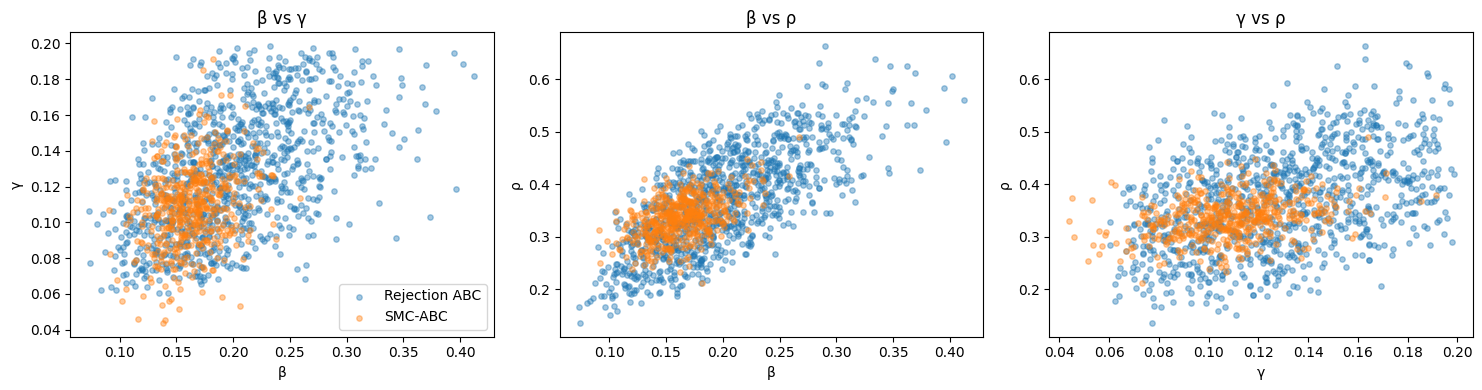

In [24]:
scatter_rejection_vs_smc(samples, particles)

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def compare_rejection_vs_smc(samples, particles):

    #  match sample sizes (fair comparison)
    n = min(len(samples), len(particles))
    samples = samples[:n]
    particles = particles[:n]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    param_names = ["β", "γ", "ρ"]

    y_max_global = 0  # track max y for all plots

    hist_data = []

    #  compute all histograms first (to fix y-axis later)
    for j in range(3):

        all_vals = np.concatenate([samples[:, j], particles[:, j]])
        bins = np.linspace(all_vals.min(), all_vals.max(), 40)

        hist_s, _ = np.histogram(samples[:, j], bins=bins, density=True)
        hist_p, _ = np.histogram(particles[:, j], bins=bins, density=True)

        y_max = max(hist_s.max(), hist_p.max())
        y_max_global = max(y_max_global, y_max)

        hist_data.append((bins, hist_s, hist_p))

    #  plot with fixed axes
    for j in range(3):

        bins, _, _ = hist_data[j]

        axes[j].hist(samples[:, j], bins=bins, alpha=0.5,
                     label="Rejection ABC", density=True)

        axes[j].hist(particles[:, j], bins=bins, alpha=0.5,
                     label="SMC-ABC", density=True)

        # mean lines
        axes[j].axvline(np.mean(samples[:, j]), linestyle="--", linewidth=1)
        axes[j].axvline(np.mean(particles[:, j]), linestyle="--", linewidth=1)

        # FIX Y AXIS
        axes[j].set_ylim(0, y_max_global * 1.1)

        axes[j].set_title(f"{param_names[j]} Posterior")
        axes[j].legend()

    plt.tight_layout()
    plt.show()

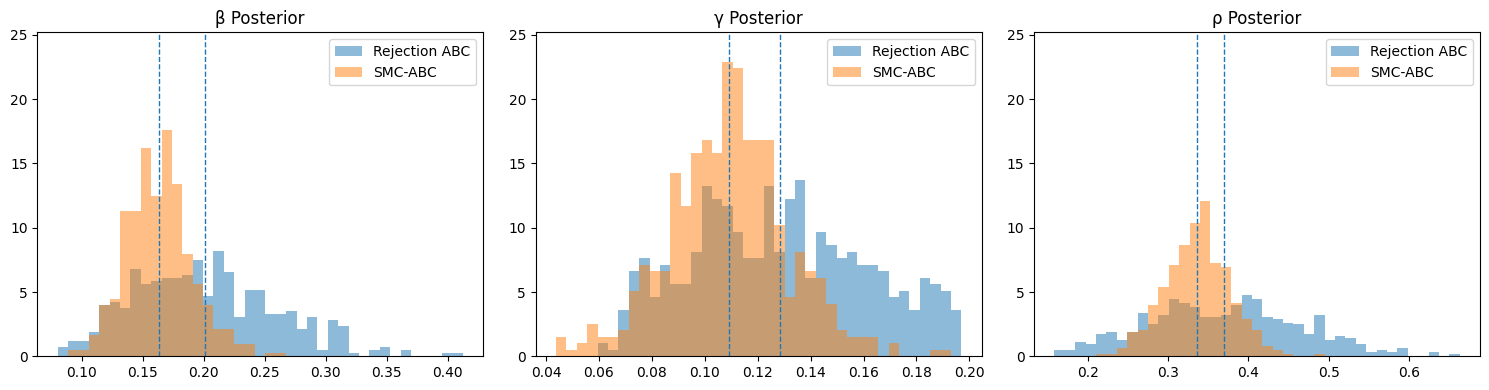

In [26]:
compare_rejection_vs_smc(samples, particles)